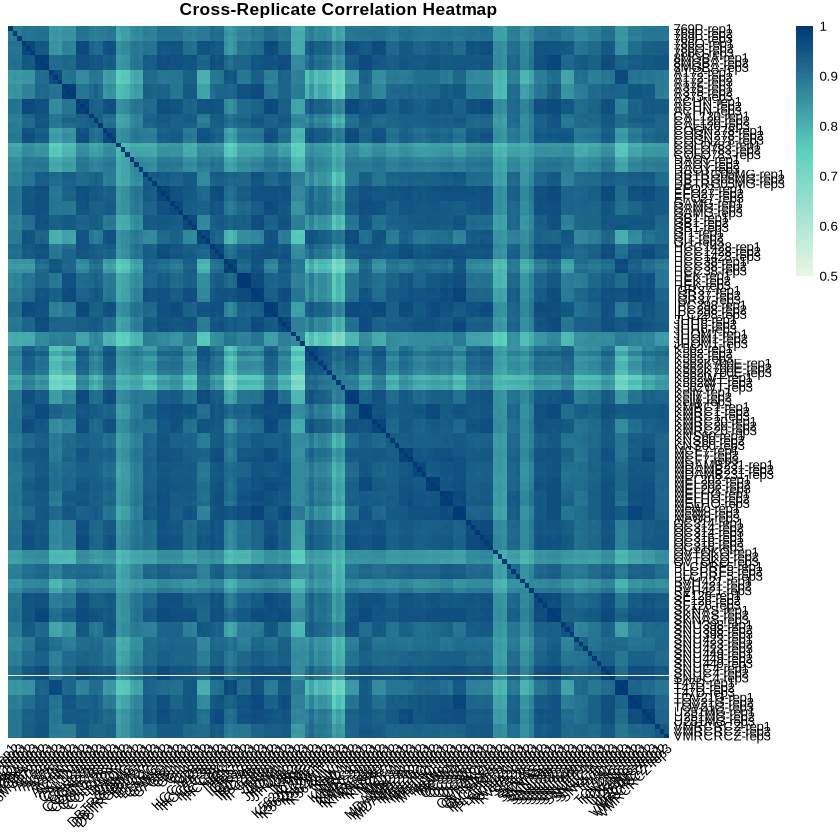

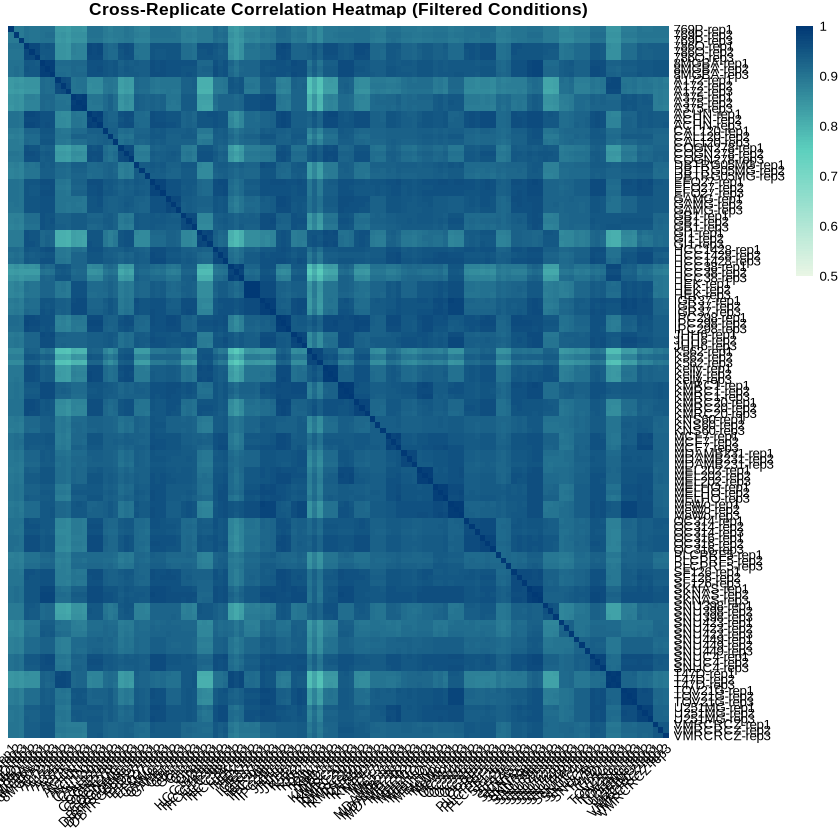

In [4]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)
library(ggpubr)

output_filepath <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/figure_outputs"
# Create output directory if it doesn't exist
if (!dir.exists(output_filepath)) {
  dir.create(output_filepath)
}

# Now I kinda want to plot the heatmap. 
final_psi_table_filtered <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  mutate(index_offset = paste(index, offset, sep = "__")) %>% 
  select(-index, -offset, -mode) %>%
  mutate(total_count = included_count + skipped_count) %>%
  filter(total_count >= 10) %>%
  mutate(PSI = included_count/(included_count + skipped_count)) 

final_psi_table_pivot <- final_psi_table_filtered %>%
  select(sample, index_offset, PSI) %>%
  pivot_wider(names_from = c(sample), values_from = PSI) 

# Plot a violin plot per cell line using custom gradient colors
# Create the plot with custom color gradient
p1 <- ggplot(final_psi_table_filtered, aes(x = condition, y = PSI, fill = PSI)) + 
  geom_violin(trim = TRUE, alpha = 0.7, fill = "#A6CEE3") +  
  theme_classic(base_size = 14) +  
  labs(
    title = "Distribution of PSI Across Conditions",
    x = "Condition",
    y = "Percent Spliced-In (PSI)"
  ) + 
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    legend.position = "right",
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

ggsave(filename = file.path(output_filepath, "all_samples_violin_plot_new_data_all_offsets.pdf"), plot = p1, width = 12, height = 6, dpi = 300)

# Also plot for offset == 0:0:0
final_psi_table_filtered <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(offset == "0:0:0") %>% 
  mutate(index_offset = paste(index, offset, sep = "__")) %>% 
  select(-index, -offset, -mode) %>%
  mutate(total_count = included_count + skipped_count) %>%
  filter(total_count >= 10) %>%
  mutate(PSI = included_count/(included_count + skipped_count)) 


final_psi_table_pivot <- final_psi_table_filtered %>%
  select(sample, index_offset, PSI) %>%
  pivot_wider(names_from = c(sample), values_from = PSI) 

# Create the plot with custom color gradient
p1 <- ggplot(final_psi_table_filtered, aes(x = condition, y = PSI, fill = PSI)) + 
  geom_violin(trim = TRUE, alpha = 0.7, fill = "#A6CEE3") +  
  theme_classic(base_size = 14) +  
  labs(
    title = "Distribution of PSI Across Conditions",
    x = "Condition",
    y = "Percent Spliced-In (PSI)"
  ) + 
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    legend.position = "right",
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

ggsave(filename = file.path(output_filepath, "all_samples_violin_plot_new_data_offset_zero.pdf"), plot = p1, width = 12, height = 6, dpi = 300)


# Plot cross replicate correlation for all samples
# Use custom color palette for heatmap with the specified gradient colors
heatmap_colors <- colorRampPalette(c("#E9F6E5", "#5DD0BE", "#003674"))(100)
breaks <- seq(0.5, 1, length.out = 100)

# Compute correlation matrix
correlation_matrix <- cor(final_psi_table_pivot %>% select(-index_offset), use = "pairwise.complete.obs")

# Plot heatmap with enhanced aesthetics and custom color palette
p2 <- pheatmap(correlation_matrix, 
               color = heatmap_colors, 
               cluster_rows = F,   # Allow clustering for better visualization
               cluster_cols = F,   # Allow clustering for better visualization
               fontsize = 8,         # Increased font size for readability
               border_color = "grey90", # Subtle grid lines
               breaks = breaks,
               main = "Cross-Replicate Correlation Heatmap",
               treeheight_row = 10,  # Reduce tree height for better spacing
               treeheight_col = 10,
               angle_col = 45)       # Tilt column labels for readability

# Save high-resolution image
ggsave(file.path(output_filepath,"CrossReplicate_Correlation_Heatmap_new_data_offset_zero.pdf"), plot = p2, dpi = 300, width = 17, height = 16)
  
# Filter out the bad conditions.
bad_conditions <- c("DAOY", "COLO783", "JHOM1", "RVH421", "OVTOKO", "K562WT", "K562K700E")

final_psi_table_filtered_filtered <- final_psi_table_filtered %>% 
  filter(!condition %in% bad_conditions)

final_psi_table_pivot_filtered <- final_psi_table_filtered_filtered %>%
  select(sample, index_offset, PSI) %>%
  pivot_wider(names_from = c(sample), values_from = PSI)

# Compute correlation matrix
correlation_matrix_filtered <- cor(final_psi_table_pivot_filtered %>% select(-index_offset), use = "pairwise.complete.obs")

# Plot heatmap with enhanced aesthetics and custom color palette
p3 <- pheatmap(correlation_matrix_filtered, 
               color = heatmap_colors, 
               cluster_rows = F,   # Allow clustering for better visualization
               cluster_cols = F,   # Allow clustering for better visualization
               fontsize = 8,         # Increased font size for readability
               border_color = NA, # Subtle grid lines
               breaks = breaks,
               main = "Cross-Replicate Correlation Heatmap (Filtered Conditions)",
               treeheight_row = 10,  # Reduce tree height for better spacing
               treeheight_col = 10,
               angle_col = 45)       # Tilt column labels for readability

# Save high-resolution image
ggsave(file.path(output_filepath,"CrossReplicate_Correlation_Heatmap_Filtered.pdf"), plot = p3, dpi = 300, width = 17, height = 16)

# all_samples_df <- fread("C:/Users/dawnxi/Dropbox (Harvard University)/02Splicing/latest/all_sample_reps_PSI.csv")

# all_samples_df <- all_samples_df  %>% filter((count + skipped) > 10) 

# all_samples_pivot <- all_samples_df %>% 
#   select(index, sample, PSI) %>%
#   pivot_wider(names_from = c(sample), values_from = PSI)

# # Plot the violin plot for all samples.
# p4 <- ggplot(all_samples_df, aes(x = condition, y = PSI)) + 
#   geom_violin(fill = pastel_color, color = "black", trim = TRUE, alpha = 0.7) +  # Single pastel color
#   # geom_boxplot(width = 0.1, outlier.shape = NA, fill = "white", color = "black") +  # Boxplot with white fill
#   stat_summary(fun = median, geom = "point", shape = 23, size = 3, fill = "black") +  # Highlight median
#   theme_classic(base_size = 14) +  
#   labs(
#     title = "Distribution of PSI Across Conditions",
#     x = "Condition",
#     y = "Percent Spliced-In (PSI)"
#   ) + 
#   theme(
#     axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
#     legend.position = "none",
#     plot.title = element_text(face = "bold", hjust = 0.5)
#   )

# ggsave(filename = file.path(output_filepath, "all_samples_violin_plot_old_data.pdf"), plot = p4, width = 12, height = 6, dpi = 300)

# Compute correlation matrix
# correlation_matrix_all_samples <- cor(all_samples_pivot %>% select(-index), use = "pairwise.complete.obs")

# # Plot heatmap with enhanced aesthetics
# p5 <- pheatmap(correlation_matrix_all_samples, 
#                color = heatmap_colors, 
#                cluster_rows = F,   # Allow clustering for better visualization
#                cluster_cols = F,   # Allow clustering for better visualization
#                fontsize = 8,         # Increased font size for readability
#                border_color = "grey90", # Subtle grid lines
#                main = "Cross-Replicate Correlation Heatmap (All Samples)",
#                treeheight_row = 10,  # Reduce tree height for better spacing
#                treeheight_col = 10,
#                angle_col = 45)       # Tilt column labels for readability

# # Save high-resolution image
# ggsave(file.path(output_filepath,"CrossReplicate_Correlation_Heatmap_old_data.pdf"), plot = p5, dpi = 300, width = 17, height = 16)

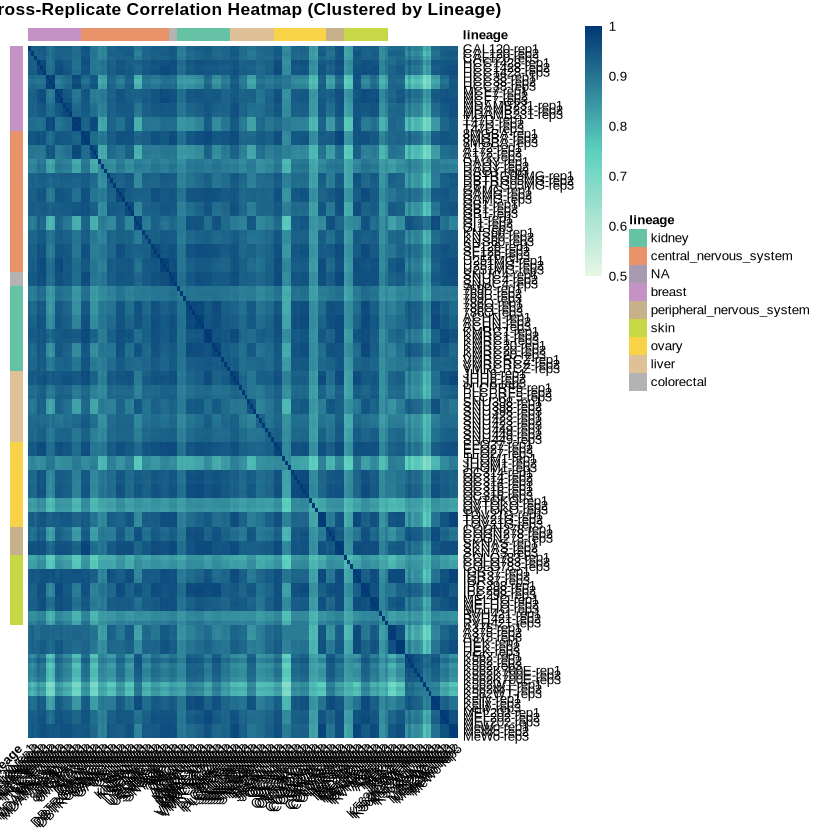

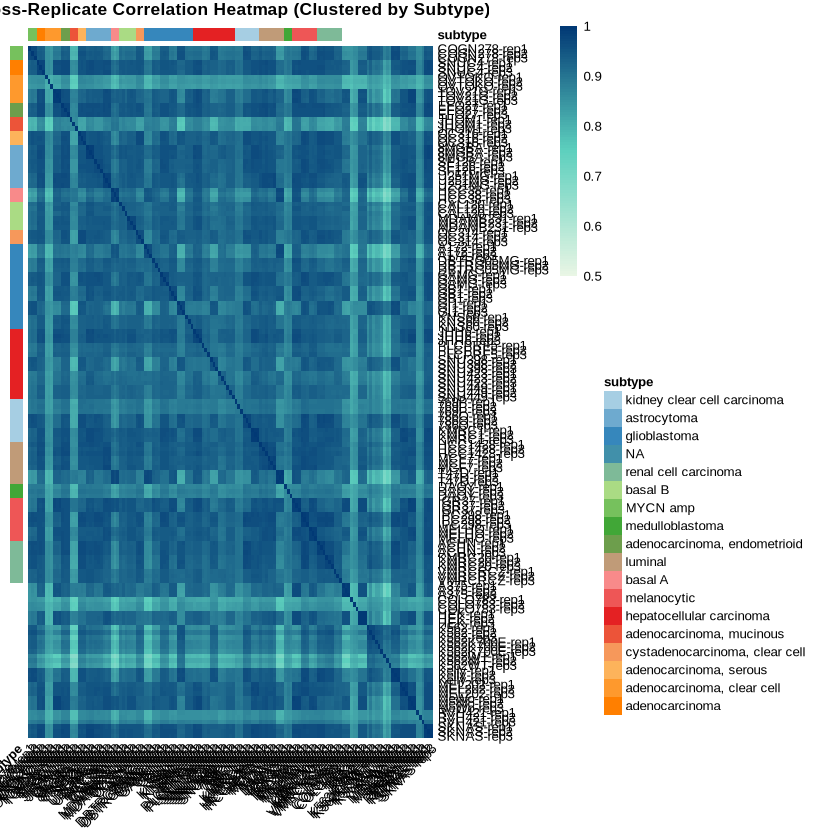

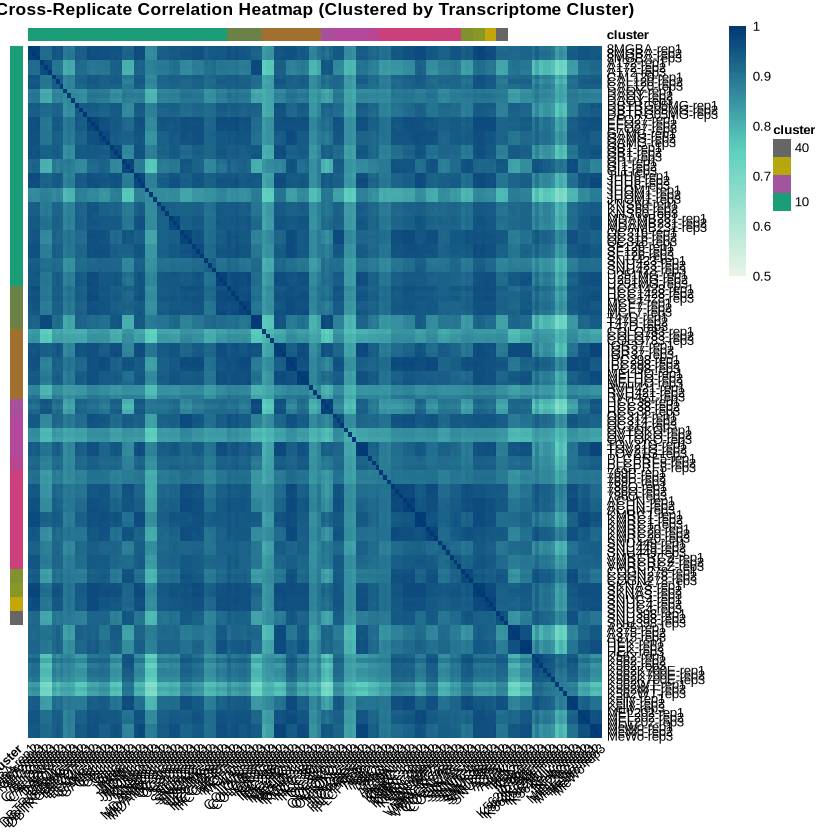

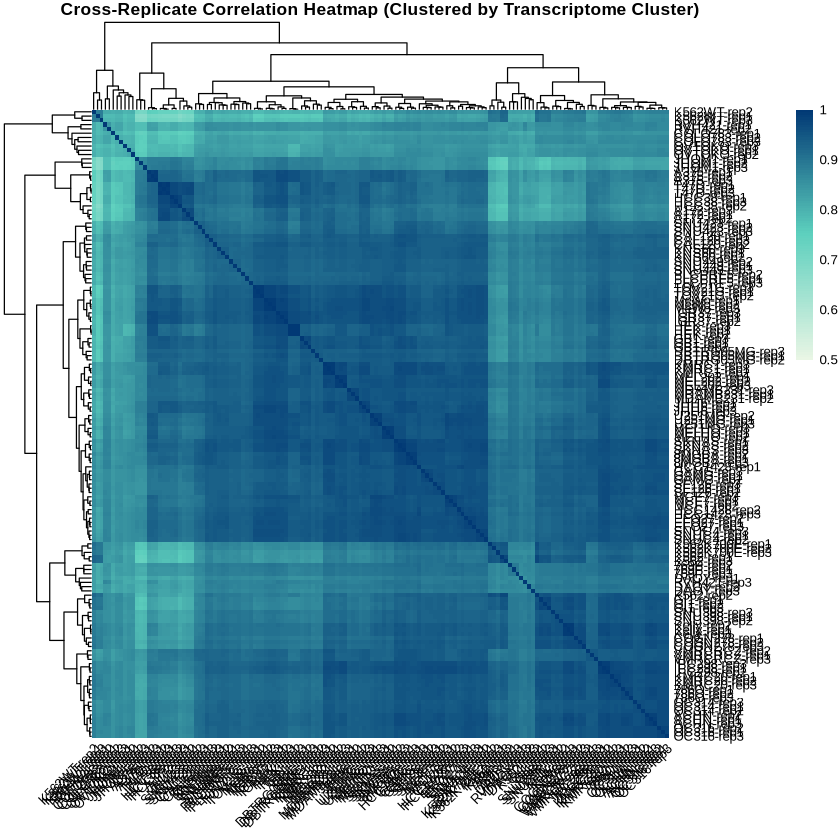

In [15]:
# Cell line metadata
cellline_metadata <- fread("/mnt/dawnccle2/melange/data/cellline_data_with_cluster.csv") %>% 
  select(display_name, lineage, subtype, cluster)

unique_sample_condition_metadata <- final_psi_table_filtered %>% 
  select(sample, condition) %>% 
  unique()

unique_sample_condition_metadata <- unique_sample_condition_metadata %>% 
  left_join(cellline_metadata, by = c("condition" = "display_name"))
# Order samples by different metadata variables for heatmaps
sample_order_lineage <- unique_sample_condition_metadata %>%
  arrange(lineage) %>%
  pull(sample)

sample_order_subtype <- unique_sample_condition_metadata %>%
  arrange(subtype) %>%
  pull(sample)

sample_order_cluster <- unique_sample_condition_metadata %>%
  arrange(cluster) %>%
  pull(sample)

# Reorder correlation matrices by different metadata
ordered_correlation_matrix_lineage <- correlation_matrix[sample_order_lineage, sample_order_lineage]
ordered_correlation_matrix_subtype <- correlation_matrix[sample_order_subtype, sample_order_subtype]
ordered_correlation_matrix_cluster <- correlation_matrix[sample_order_cluster, sample_order_cluster]

# Create annotation dataframes for each heatmap
annotation_df_lineage <- unique_sample_condition_metadata %>%
  column_to_rownames("sample") %>%
  select(lineage)

annotation_df_subtype <- unique_sample_condition_metadata %>%
  column_to_rownames("sample") %>%
  select(subtype)

annotation_df_cluster <- unique_sample_condition_metadata %>%
  column_to_rownames("sample") %>%
  select(cluster)

# Define colors for annotations
lineage_colors <- colorRampPalette(brewer.pal(8, "Set2"))(length(unique(annotation_df_lineage$lineage)))
names(lineage_colors) <- unique(annotation_df_lineage$lineage)
annotation_colors_lineage <- list(
  lineage = lineage_colors
)

subtype_colors <- colorRampPalette(brewer.pal(8, "Paired"))(length(unique(annotation_df_subtype$subtype)))
names(subtype_colors) <- unique(annotation_df_subtype$subtype)
annotation_colors_subtype <- list(
  subtype = subtype_colors
)

cluster_colors <- colorRampPalette(brewer.pal(8, "Dark2"))(length(unique(annotation_df_cluster$cluster)))
names(cluster_colors) <- unique(annotation_df_cluster$cluster)
annotation_colors_cluster <- list(
  cluster = cluster_colors
)

# Plot heatmap clustered by lineage
p_lineage <- pheatmap(ordered_correlation_matrix_lineage,
                      color = heatmap_colors,
                      breaks = breaks,
                      annotation_row = annotation_df_lineage,
                      annotation_col = annotation_df_lineage,
                      annotation_colors = annotation_colors_lineage,
                      cluster_rows = FALSE,
                      cluster_cols = FALSE,
                      fontsize = 8,
                      border_color = NA,
                      main = "Cross-Replicate Correlation Heatmap (Clustered by Lineage)",
                      angle_col = 45)

# Plot heatmap clustered by subtype
p_subtype <- pheatmap(ordered_correlation_matrix_subtype,
                      color = heatmap_colors,
                      breaks = breaks,
                      annotation_row = annotation_df_subtype,
                      annotation_col = annotation_df_subtype,
                      annotation_colors = annotation_colors_subtype,
                      cluster_rows = FALSE,
                      cluster_cols = FALSE,
                      fontsize = 8,
                      border_color = NA,
                      main = "Cross-Replicate Correlation Heatmap (Clustered by Subtype)",
                      angle_col = 45)

# Plot heatmap clustered by cluster
p_cluster <- pheatmap(ordered_correlation_matrix_cluster,
                      color = heatmap_colors,
                      breaks = breaks,
                      annotation_row = annotation_df_cluster,
                      annotation_col = annotation_df_cluster,
                      annotation_colors = annotation_colors_cluster,
                      cluster_rows = FALSE,
                      cluster_cols = FALSE,
                      fontsize = 8,
                      border_color = NA,
                      main = "Cross-Replicate Correlation Heatmap (Clustered by Transcriptome Cluster)",
                      angle_col = 45)

# Plot heatmap with pheatmap clustering. 
p_clustered <- pheatmap(correlation_matrix,
                       color = heatmap_colors,
                       breaks = breaks,
                       cluster_rows = TRUE,
                       cluster_cols = TRUE,
                       fontsize = 8,
                       border_color = NA,
                       main = "Cross-Replicate Correlation Heatmap (Clustered by Transcriptome Cluster)",
                       angle_col = 45)

# Save the heatmaps
ggsave(file.path(output_filepath, "CrossReplicate_Correlation_Heatmap_Clustered_by_Lineage.pdf"), 
       plot = p_lineage, dpi = 300, width = 17, height = 16)

ggsave(file.path(output_filepath, "CrossReplicate_Correlation_Heatmap_Clustered_by_Subtype.pdf"), 
       plot = p_subtype, dpi = 300, width = 17, height = 16)

ggsave(file.path(output_filepath, "CrossReplicate_Correlation_Heatmap_Clustered_by_Cluster.pdf"), 
       plot = p_cluster, dpi = 300, width = 17, height = 16)

ggsave(file.path(output_filepath, "CrossReplicate_Correlation_Heatmap_Clustered_by_Transcriptome_Cluster.pdf"), 
       plot = p_clustered, dpi = 300, width = 17, height = 16)
